In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [14]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]
    
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

In [15]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [16]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")
builder.add_edge("cleanup", "__end__")

In [17]:
graph = builder.compile(checkpointer=InMemorySaver())

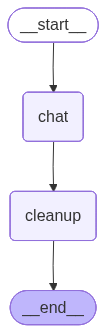

In [18]:
graph

In [19]:
config = {"configurable": {"thread_id": "t1"}}

In [20]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Aashir"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='d7f63bb3-ef9d-4761-b88b-25f7150cebeb'),
  AIMessage(content="LangChain is a powerful framework for building language models and AI applications. It's designed to simplify the development process and make it easier to integrate language models with other AI technologies.\n\n**What is LangChain?**\n\nLangChain is an open-source, Python-based framework that provides a set of tools and APIs for building language models, chatbots, and other AI applications. It's built on top of the LangChain Engine, which is a high-performance language processing engine that can handle large volumes of text data.\n\n**Key Features of LangChain**\n\nLangChain offers a range of features that make it an attractive choice for developers, including:\n\n1. **Easy model deployment**: LangChain provides a simple way to deploy and manage language models, making it easy to integrate them with other AI applications.

In [21]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
